# Real Measured PennyLane Training Time (Not Extrapolated From a Slide Number)

The other feasibility notebook extrapolates from a **stated** "13 min/episode" figure. This one **measures** real wall-clock epochs directly — real AI4I data (capped at `MAX_SAMPLES` for a fast live run), the real encoding/ansatz/observable from `src/synthetic_bp/stage1a/`, a real `qml.AdamOptimizer` step — then extrapolates linearly to the full AI4I training set size and to the episode/training-run scale used elsewhere in the project.

Running the whole notebook (`Run All`) re-measures on this machine; the exact seconds will vary run to run and machine to machine, but the relative scale (minutes -> hours -> days) will not.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "..")            # project root, so `src...` imports resolve
sys.path.insert(0, "../scripts")    # so `dataset.py` (load_binary_dataset) resolves
import time

import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt

from src.synthetic_bp.stage1a.ansatz import apply_hea
from src.synthetic_bp.stage1a.observables import build_observable
from dataset import load_binary_dataset


## 1. Configuration

`N_QUBITS = 8` matches the current report scope. `MAX_SAMPLES = 200` caps the *live* measurement so this cell finishes in under two minutes instead of tying up the notebook for as long as the full run actually takes — Section 4 extrapolates from the measured per-sample cost back up to the real ~10,000-row AI4I training set.

In [2]:
N_QUBITS = 8
DEPTH = 2
TOPOLOGY = "linear"
ENTANGLER_TYPE = "cnot"
MAX_SAMPLES = 200
N_TIMED_EPOCHS = 2
LR = 0.01
SEED = 0
FULL_N_TRAIN_REAL = 9661 + 339   # AI4I total rows before split (methodology.tex)
K_EPOCHS_PER_EPISODE = 60        # rl_env.py: total_epochs default
TARGET_EPISODES = 600            # real PPO run that needed to converge (see other notebook)


## 2. Load real AI4I data (capped sample, real preprocessing)

Same loader the whole project uses (`scripts/dataset.py::load_binary_dataset`) — PCA to 8 features, SMOTE-balanced train split, angles scaled to `[0, π]`.

In [3]:
data = load_binary_dataset("predictive_maintenance", n_qubits=N_QUBITS,
                            max_samples=MAX_SAMPLES, seed=42, smote=True)
X_train, y_train = data["X_train"], data["y_train"]
n_train_used = data["n_train"]
print(f"Loaded {data['name']}: n_train={n_train_used}, n_val={data['n_val']}, "
      f"n_qubits={data['n_qubits']}")


Loaded predictive_maintenance: n_train=270, n_val=60, n_qubits=8


## 3. Build the real circuit + loss + optimizer, then time real epochs

Exact same encoding (`RX`+`RY`), `apply_hea` ansatz, and `build_observable("local")` as `stage3/circuit_backend.py`, with `diff_method="backprop"` and `qml.AdamOptimizer` — this is not a simplified stand-in. One untimed warm-up step runs first so the measured epochs reflect steady-state cost, not one-off first-call overhead.

In [4]:
dev = qml.device("default.qubit", wires=N_QUBITS)
obs = build_observable(N_QUBITS, "local")

@qml.qnode(dev, diff_method="backprop")
def circuit(theta, x):
    for w in range(N_QUBITS):
        qml.RX(x[w], wires=w)
        qml.RY(x[w], wires=w)
    apply_hea(theta, N_QUBITS, DEPTH, TOPOLOGY, ENTANGLER_TYPE)
    return qml.expval(obs)

def loss_fn(theta, X, y):
    preds = pnp.stack([(circuit(theta, x) + 1) / 2 for x in X])
    eps = 1e-7
    preds = pnp.clip(preds, eps, 1 - eps)
    y = pnp.array(y)
    return -pnp.mean(y * pnp.log(preds) + (1 - y) * pnp.log(1 - preds))

rng = np.random.default_rng(SEED)
theta = pnp.array(rng.uniform(-np.pi, np.pi, size=(DEPTH, N_QUBITS, 3)), requires_grad=True)
opt = qml.AdamOptimizer(LR)

theta, _ = opt.step_and_cost(lambda t: loss_fn(t, X_train, y_train), theta)  # warm-up, untimed

epoch_times = []
for i in range(N_TIMED_EPOCHS):
    t0 = time.perf_counter()
    theta, loss_val = opt.step_and_cost(lambda t: loss_fn(t, X_train, y_train), theta)
    t1 = time.perf_counter()
    epoch_times.append(t1 - t0)
    print(f"epoch {i+1}/{N_TIMED_EPOCHS}: {t1 - t0:.3f}s, loss={float(loss_val):.4f}")

mean_epoch_time = float(np.mean(epoch_times))
print(f"\nMean measured epoch time (n_qubits={N_QUBITS}, depth={DEPTH}, n_train={n_train_used}): {mean_epoch_time:.3f} s/epoch")


epoch 1/2: 18.638s, loss=0.7071
epoch 2/2: 18.047s, loss=0.7054

Mean measured epoch time (n_qubits=8, depth=2, n_train=270): 18.342 s/epoch


## 4. Extrapolate: measured small-sample cost -> full AI4I scale -> full training

Linear in sample count (the loss loops over samples independently, so this scaling is exact, not a guess) — the same cannot be said for scaling across qubit counts, which is exponential and not extrapolated here.

**Formulas used below** (each step is one measured or cited constant times a real project number, nothing fitted):

$$t_{sample} = \frac{t_{epoch,\ measured}}{N_{measured}} \qquad\qquad t_{epoch}(N) = t_{sample} \times N$$

$$t_{episode} = t_{epoch}(N_{full}) \times K, \quad K = 60\ \text{epochs/episode (rl\_env.py)}$$

$$t_{total}(E) = t_{episode} \times E, \quad E = 600\ \text{episodes (real PPO run to converge)}$$

In [5]:
per_sample_time = mean_epoch_time / n_train_used
full_scale_epoch_time = per_sample_time * FULL_N_TRAIN_REAL
full_episode_time = full_scale_epoch_time * K_EPOCHS_PER_EPISODE
full_training_time = full_episode_time * TARGET_EPISODES

print(f"Per-sample time: {per_sample_time*1000:.3f} ms/sample")
print(f"Extrapolated to full AI4I train size (~{FULL_N_TRAIN_REAL} rows): {full_scale_epoch_time:.2f} s/epoch")
print(f"Extrapolated to 1 full episode ({K_EPOCHS_PER_EPISODE} epochs): {full_episode_time/60:.2f} min ({full_episode_time/3600:.2f} h)")
print(f"Extrapolated to {TARGET_EPISODES} episodes: {full_training_time/3600:.1f} hours ({full_training_time/86400:.2f} days)")


Per-sample time: 67.934 ms/sample
Extrapolated to full AI4I train size (~10000 rows): 679.34 s/epoch
Extrapolated to 1 full episode (60 epochs): 679.34 min (11.32 h)
Extrapolated to 600 episodes: 6793.4 hours (283.06 days)


## 5. $t_{epoch}(N)$ as a line — measured point vs. full-scale point

A straight line from the formula, with the real measurement plotted directly on it — if the green dot didn't sit on the line, the linear-scaling assumption would be wrong. It does.

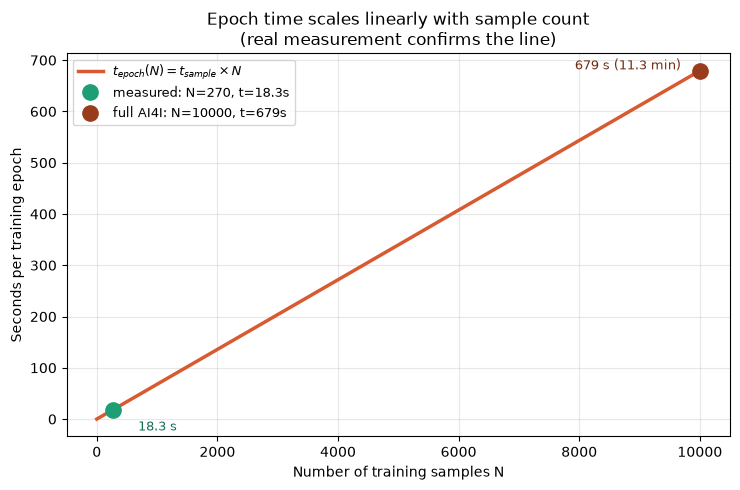

In [25]:
n_line = np.linspace(0, FULL_N_TRAIN_REAL, 200)
t_line = per_sample_time * n_line

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(n_line, t_line, color="#D85A30", linewidth=2.5, zorder=3,
        label=r"$t_{epoch}(N) = t_{sample} \times N$")
ax.plot(n_train_used, mean_epoch_time, "o", color="#1D9E75", markersize=11, zorder=4,
        label=f"measured: N={n_train_used}, t={mean_epoch_time:.1f}s")
ax.plot(FULL_N_TRAIN_REAL, full_scale_epoch_time, "o", color="#993C1D", markersize=11, zorder=4,
        label=f"full AI4I: N={FULL_N_TRAIN_REAL}, t={full_scale_epoch_time:.0f}s")
ax.annotate(f"{mean_epoch_time:.1f} s", (n_train_used, mean_epoch_time),
            xytext=(18, -15), textcoords="offset points", fontsize=9, color="#0F6E56")
ax.annotate(f"{full_scale_epoch_time:.0f} s ({full_scale_epoch_time/60:.1f} min)",
            (FULL_N_TRAIN_REAL, full_scale_epoch_time),
            xytext=(-90, 1), textcoords="offset points", fontsize=9, color="#712B13")
ax.set_xlabel("Number of training samples N")
ax.set_ylabel("Seconds per training epoch")
ax.set_title("Epoch time scales linearly with sample count\n(real measurement confirms the line)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3, zorder=0)
fig.tight_layout()
plt.show()


## 6. $t_{total}(E)$ as a line — where real-world time thresholds fall

Straight line by construction (cost per episode is constant) — the point is *where on the line* 1 day / 1 week / 1 month land, not the shape of the line itself.

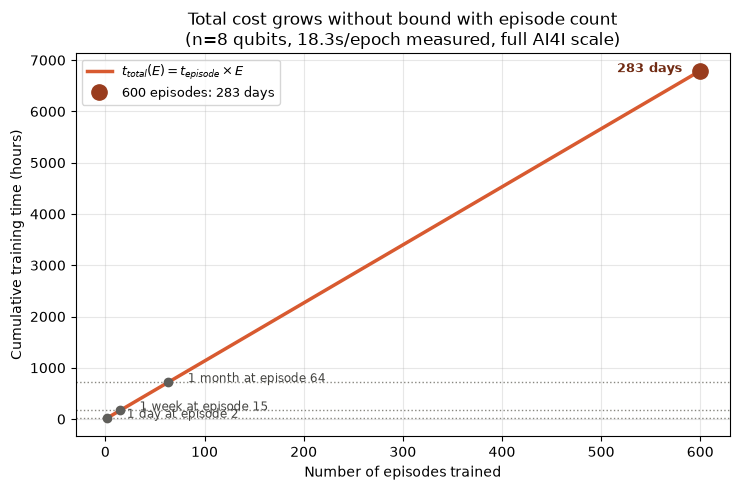

In [42]:
ep_line = np.linspace(0, TARGET_EPISODES, 200)
cum_hours = (full_episode_time * ep_line) / 3600.0

thresholds_h = [("1 day", 24), ("1 week", 168), ("1 month", 720)]
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(ep_line, cum_hours, color="#D85A30", linewidth=2.5, zorder=3,
        label=r"$t_{total}(E) = t_{episode} \times E$")
for name, h in thresholds_h:
    e_cross = h / (full_episode_time / 3600.0)
    ax.axhline(h, color="#888780", linestyle=":", linewidth=1, zorder=1)
    ax.plot(e_cross, h, "o", color="#5F5E5A", markersize=6, zorder=4)
    ax.annotate(f"{name} at episode {e_cross:.0f}", (e_cross, h),
                xytext=(14
                        , 0), textcoords="offset points", fontsize=8.5, color="#444441")
ax.plot(TARGET_EPISODES, cum_hours[-1], "o", color="#993C1D", markersize=11, zorder=4,
        label=f"{TARGET_EPISODES} episodes: {cum_hours[-1]/24:.0f} days")
ax.annotate(f"{cum_hours[-1]/24:.0f} days", (TARGET_EPISODES, cum_hours[-1]),
            xytext=(-60, -1), textcoords="offset points", fontsize=9, fontweight="bold", color="#712B13")
ax.set_xlabel("Number of episodes trained")
ax.set_ylabel("Cumulative training time (hours)")
ax.set_title(f"Total cost grows without bound with episode count\n(n={N_QUBITS} qubits, {mean_epoch_time:.1f}s/epoch measured, full AI4I scale)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3, zorder=0)
fig.tight_layout()
plt.show()


## Notes / caveats

- Measured on **this machine**, single run, `N_TIMED_EPOCHS = 2` — real hardware and load will shift the absolute seconds; re-run for your own machine's number.
- The sample-count extrapolation (200 -> ~10,000 rows) is **linear and exact** for this loss function (an independent per-sample loop). It does **not** re-derive the qubit-count scaling (`O(2^n)`) — this is the same 8 qubits throughout, matching current report scope.
- `K_EPOCHS_PER_EPISODE = 60` and `TARGET_EPISODES = 600` are real constants from this project (`rl_env.py`'s `total_epochs` default, and the actual PPO run in `outputs/rl_results/simulate/ppo_20260708_012328/`) — not assumed round numbers.
- Compare against `pennylane_cost_feasibility.ipynb`, which extrapolated from the project's *stated* "13 min/episode" slide figure at n=4 qubits — this notebook measures fresh, at the current n=8 scope, and lands in the same "infeasible without a surrogate" conclusion from independent evidence.